# Telco Customer Churn: Feature Engineering, Model Building and Scaling




## 0. Environment Setup




In [1]:
!pip install -q kagglehub scikit-learn pandas numpy matplotlib seaborn xgboost


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    print("xgboost not available, it will be skipped and Gradient Boosting will represent that family instead.")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 1. Download the Dataset

The cell below uses kagglehub exactly as provided in the assignment brief to fetch the latest version of the dataset directly inside Colab.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [4]:
import os

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("Files found:", csv_files)

data_path = os.path.join(path, csv_files[0])
df = pd.read_csv(data_path)
df.head()


Files found: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 1: Data Preparation

### 1.1 Inspect shape, dtypes and missing values

Before touching anything we look at the raw structure of the data so every later decision is based on evidence rather than assumption.


In [5]:
print("Shape:", df.shape)
print()
df.info()


Shape: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


No column is reported as null by pandas, yet the assignment brief warns that `TotalCharges` hides blank strings rather than proper NaN values. This is a common data quality trap: a column that looks numeric on the surface is actually stored as text because a handful of rows contain empty strings, which silently turns the whole column into an object dtype.


In [7]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
blank_mask = df["TotalCharges"].str.strip() == ""
print("Number of blank TotalCharges values:", blank_mask.sum())
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


TotalCharges dtype: object
Number of blank TotalCharges values: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


### 1.2 Fix TotalCharges

Every blank row above has `tenure` equal to zero. These are brand new customers who have not been billed a full cycle yet, so `TotalCharges` is genuinely undefined rather than missing at random. The most defensible fix is to convert the column to numeric and set these specific rows to 0, which matches the underlying business reality instead of guessing an average value that would not represent a brand new customer.


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Remaining nulls in TotalCharges:", df["TotalCharges"].isnull().sum())
df["TotalCharges"].describe()


Remaining nulls in TotalCharges: 0


,TotalCharges
count,7043.000000
mean,2279.734304
std,2266.794470
min,0.000000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


### 1.3 Drop identifier columns

`customerID` is a unique string per row. It carries zero predictive signal and would only add noise or, worse, act as a leak if accidentally encoded, so it is removed now.


In [9]:
df = df.drop(columns=["customerID"])
df.shape


(7043, 20)

### 1.4 Confirm and inspect the target variable

We check that `Churn` only contains the two expected labels and look at the class balance, since an imbalanced target changes how we should read accuracy later.


['No' 'Yes']
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


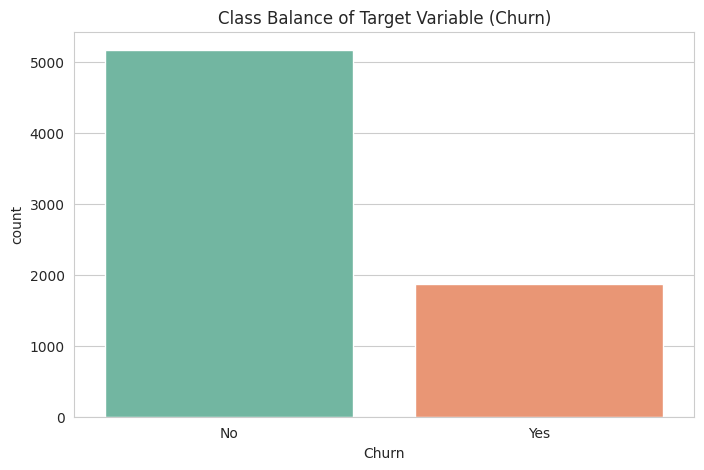

In [10]:
print(df["Churn"].unique())
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))

sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Class Balance of Target Variable (Churn)")
plt.show()


The dataset is mildly imbalanced: churned customers make up roughly a quarter of the data. This is exactly why the assignment requires precision, recall, F1 and ROC AUC in addition to accuracy, since a model could reach around 73 percent accuracy simply by predicting the majority class every time.


## Task 2: Feature Engineering

### 2.1 Encode the target

`Churn` is converted to a binary integer so it can be used directly by every scikit learn estimator.


In [11]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()


,count
Churn,
0,5174
1,1869


### 2.2 Engineer new features

Three new features are created below, each with a short justification.

**1. tenure_group.** Raw tenure in months is continuous and noisy for a model looking for simple thresholds. Grouping customers into New, Established and Long term buckets captures the well known business pattern that churn risk is highest in the first year and then drops sharply, a nonlinear relationship that a single linear coefficient on raw tenure cannot represent well.

**2. total_services.** This counts how many of the nine optional add on and connectivity services a customer actually subscribes to. Customers who buy many services are typically more invested in the provider, so this single count is expected to correlate negatively with churn and gives tree based and linear models an easy aggregate signal instead of forcing them to combine nine separate columns on their own.

**3. monthly_to_tenure_ratio.** This is `MonthlyCharges` divided by `tenure + 1`. It approximates how much of a customer's total historical spend is concentrated in the current month relative to their history, which helps flag customers whose bill has grown quickly relative to how long they have been with the company, a pattern often associated with price sensitive churn.


In [12]:
def tenure_bucket(t):
    if t <= 12:
        return "New"
    elif t <= 48:
        return "Established"
    else:
        return "Long_term"

df["tenure_group"] = df["tenure"].apply(tenure_bucket)

service_cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

def count_services(row):
    count = 0
    for col in service_cols:
        val = row[col]
        if val not in ["No", "No internet service", "No phone service"]:
            count += 1
    return count

df["total_services"] = df.apply(count_services, axis=1)

df["monthly_to_tenure_ratio"] = df["MonthlyCharges"] / (df["tenure"] + 1)

df[["tenure", "tenure_group", "total_services", "monthly_to_tenure_ratio"]].head()


,tenure,tenure_group,total_services,monthly_to_tenure_ratio
0,1,New,2,14.925000
1,34,Established,4,1.627143
2,2,New,4,17.950000
3,45,Established,4,0.919565
4,2,New,2,23.566667


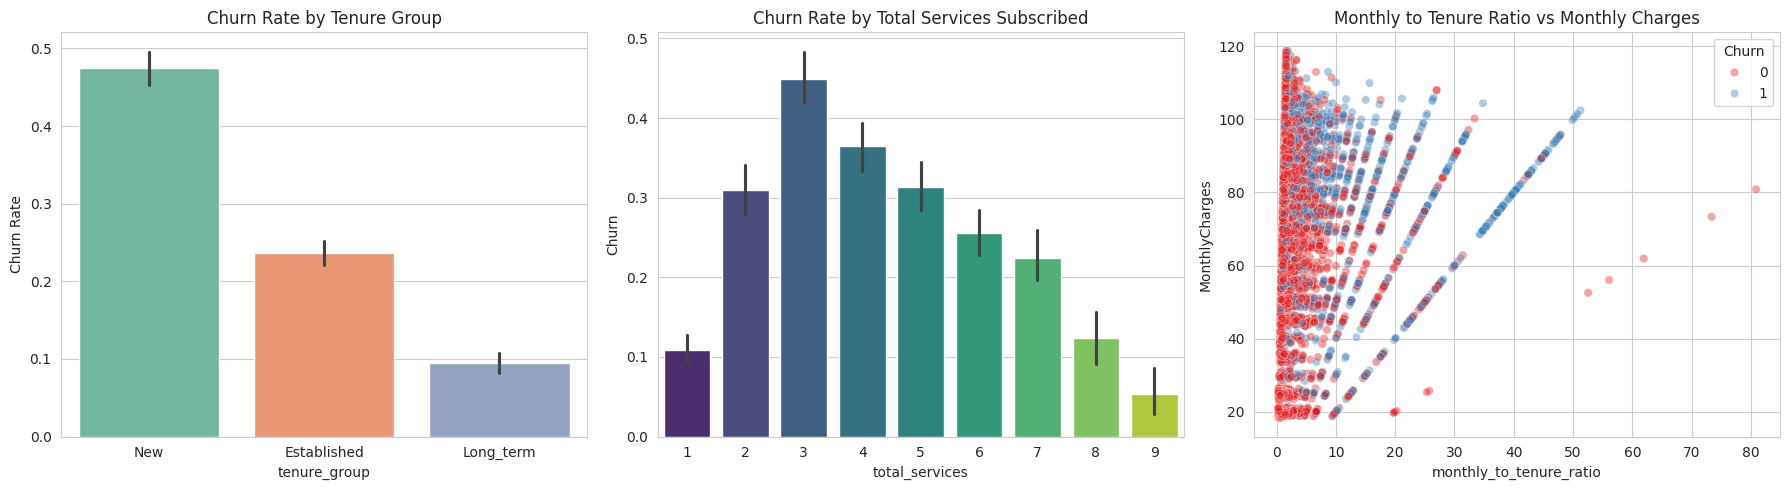

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x="tenure_group", y="Churn", order=["New", "Established", "Long_term"],
            ax=axes[0], palette="Set2")
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_ylabel("Churn Rate")

sns.barplot(data=df, x="total_services", y="Churn", ax=axes[1], palette="viridis")
axes[1].set_title("Churn Rate by Total Services Subscribed")

sns.scatterplot(data=df, x="monthly_to_tenure_ratio", y="MonthlyCharges", hue="Churn",
                 alpha=0.4, ax=axes[2], palette="Set1")
axes[2].set_title("Monthly to Tenure Ratio vs Monthly Charges")

plt.tight_layout()
plt.show()


The plots confirm the intuition behind each feature: churn rate drops sharply as tenure group moves from New to Long term, churn rate falls as customers subscribe to more services, and churned customers cluster at higher values of the monthly to tenure ratio.


### 2.3 Encode categorical variables

`Contract` has a genuine order, Month to month is shorter and less committed than One year, which is shorter than Two year, so it is encoded ordinally rather than one hot encoded. `SeniorCitizen` is already binary numeric. Every other categorical column is nominal, meaning there is no natural ranking among its categories, so those are one hot encoded to avoid implying an order that does not exist.


In [14]:
contract_order = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["Contract"] = df["Contract"].map(contract_order)

nominal_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling",
    "PaymentMethod", "tenure_group"
]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (7043, 34)


,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,total_services,monthly_to_tenure_ratio,gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_Long_term,tenure_group_New
0,0,1,0,29.85,29.85,0,2,14.925000,False,True,...,False,False,False,False,True,False,True,False,False,True
1,0,34,1,56.95,1889.50,0,4,1.627143,True,False,...,False,False,False,False,False,False,False,True,False,False
2,0,2,0,53.85,108.15,1,4,17.950000,True,False,...,False,False,False,False,True,False,False,True,False,True
3,0,45,1,42.30,1840.75,0,4,0.919565,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,0,70.70,151.65,1,2,23.566667,False,False,...,False,False,False,False,True,False,True,False,False,True


In [15]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# make sure every feature column is numeric before modeling
X = X.astype(float)
print(X.shape, y.shape)


(7043, 33) (7043,)


## Task 3: Feature Scaling

### 3.1 Which features actually need scaling

Tree based models such as Decision Tree, Random Forest and Gradient Boosting split on thresholds one feature at a time, so the absolute scale of a feature does not affect them at all. Distance based and margin based models behave very differently: K Nearest Neighbors measures raw Euclidean distance, and Support Vector Machines optimize a margin that is sensitive to the relative scale of every dimension. Logistic Regression also converges faster and produces more stable coefficients on scaled inputs. The continuous features that genuinely need scaling here are `tenure`, `MonthlyCharges`, `TotalCharges` and the two engineered numeric features `total_services` and `monthly_to_tenure_ratio`. The one hot encoded columns are already 0 or 1 and do not need scaling.


In [16]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "total_services", "monthly_to_tenure_ratio"]
X[numeric_cols].describe()


,tenure,MonthlyCharges,TotalCharges,total_services,monthly_to_tenure_ratio
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,4.146244,5.770645
std,24.559481,30.090047,2266.794470,2.312720,8.722435
min,0.000000,18.250000,0.000000,1.000000,0.264384
25%,9.000000,35.500000,398.550000,2.000000,1.250000
50%,29.000000,70.350000,1394.550000,4.000000,2.075926
75%,55.000000,89.850000,3786.600000,6.000000,5.946429
max,72.000000,118.750000,8684.800000,9.000000,80.850000


### 3.2 Train test split

The split is performed before any scaler is fit. Stratification on `Churn` keeps the same roughly 27 percent churn rate in both the training and test sets, which matters given the class imbalance noted earlier.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train shape: (5634, 33)  Test shape: (1409, 33)
Train churn rate: 0.265  Test churn rate: 0.265


### 3.3 Fit scalers on the training set only

The scaler is fit only on `X_train` and then used to transform both `X_train` and `X_test`. Fitting on the full dataset, or on the test set, would let statistics from the test data leak into the training process. That leakage produces an optimistic and unrealistic estimate of how the model performs on genuinely unseen data, which defeats the purpose of holding out a test set in the first place.


In [18]:
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[numeric_cols] = standard_scaler.fit_transform(X_train[numeric_cols])
X_test_std[numeric_cols] = standard_scaler.transform(X_test[numeric_cols])

X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
X_train_mm[numeric_cols] = minmax_scaler.fit_transform(X_train[numeric_cols])
X_test_mm[numeric_cols] = minmax_scaler.transform(X_test[numeric_cols])

X_train_std[numeric_cols].describe().round(2)


,tenure,MonthlyCharges,TotalCharges,total_services,monthly_to_tenure_ratio
count,5634.00,5634.00,5634.00,5634.00,5634.00
mean,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.54,-1.01,-1.36,-0.63
25%,-0.96,-0.97,-0.83,-0.93,-0.52
50%,-0.14,0.18,-0.40,-0.07,-0.42
75%,0.92,0.83,0.67,0.79,0.01
max,1.61,1.79,2.80,2.08,7.79


### 3.4 Which scaler is carried forward

`StandardScaler` is carried forward into modeling. `TotalCharges` and `MonthlyCharges` are right skewed with a meaningful number of higher value outliers, and `StandardScaler` centers each feature around a mean of 0 with unit variance without artificially compressing every value into a fixed 0 to 1 range the way `MinMaxScaler` does. That makes it a safer default for Logistic Regression, KNN and SVM, all of which assume features live on a comparable, roughly centered scale. `MinMaxScaler` is kept above only as a documented alternative, since it is more appropriate when a model strictly requires bounded, nonnegative inputs, which is not the case for any algorithm trained here.


## Task 4: Model Building

Seven classifiers spanning five families are trained: Logistic Regression as the linear baseline, Decision Tree and Random Forest as tree based models, Gradient Boosting and, if available, XGBoost as boosted tree models, K Nearest Neighbors as the distance based model, Support Vector Machine as the margin based model, and Gaussian Naive Bayes as the probabilistic model. Tree based and Naive Bayes models use the unscaled `X_train` and `X_test`, while Logistic Regression, KNN and SVM use the standardized versions from Task 3.


In [19]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "K Nearest Neighbors": (KNeighborsClassifier(n_neighbors=15), True),
    "Support Vector Machine": (SVC(probability=True, random_state=RANDOM_STATE), True),
    "Naive Bayes": (GaussianNB(), False),
}

if XGB_AVAILABLE:
    models["XGBoost"] = (XGBClassifier(
        n_estimators=300, use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_STATE
    ), False)


In [20]:
results = []
fitted_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, (model, needs_scaling) in models.items():
    if needs_scaling:
        Xtr, Xte = X_train_std, X_test_std
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else preds

    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring="roc_auc")

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs),
        "CV ROC AUC (mean)": cv_scores.mean(),
        "CV ROC AUC (std)": cv_scores.std(),
    })

results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV ROC AUC (mean),CV ROC AUC (std)
0,Logistic Regression,0.8034,0.6644,0.5241,0.5859,0.8461,0.8485,0.0111
1,Gradient Boosting,0.7977,0.6551,0.5027,0.5688,0.8437,0.8479,0.0122
2,K Nearest Neighbors,0.7878,0.6119,0.5481,0.5783,0.8277,0.8293,0.0080
3,Random Forest,0.7885,0.6310,0.4893,0.5512,0.8254,0.8277,0.0111
4,Naive Bayes,0.6891,0.4539,0.8422,0.5899,0.8198,0.8239,0.0114
5,XGBoost,0.7700,0.5727,0.5267,0.5487,0.8082,0.8109,0.0054
6,Support Vector Machine,0.8055,0.6838,0.4973,0.5759,0.7948,0.7953,0.0168
7,Decision Tree,0.7488,0.5282,0.5000,0.5137,0.6693,0.6542,0.0131


### 4.1 Comparison chart


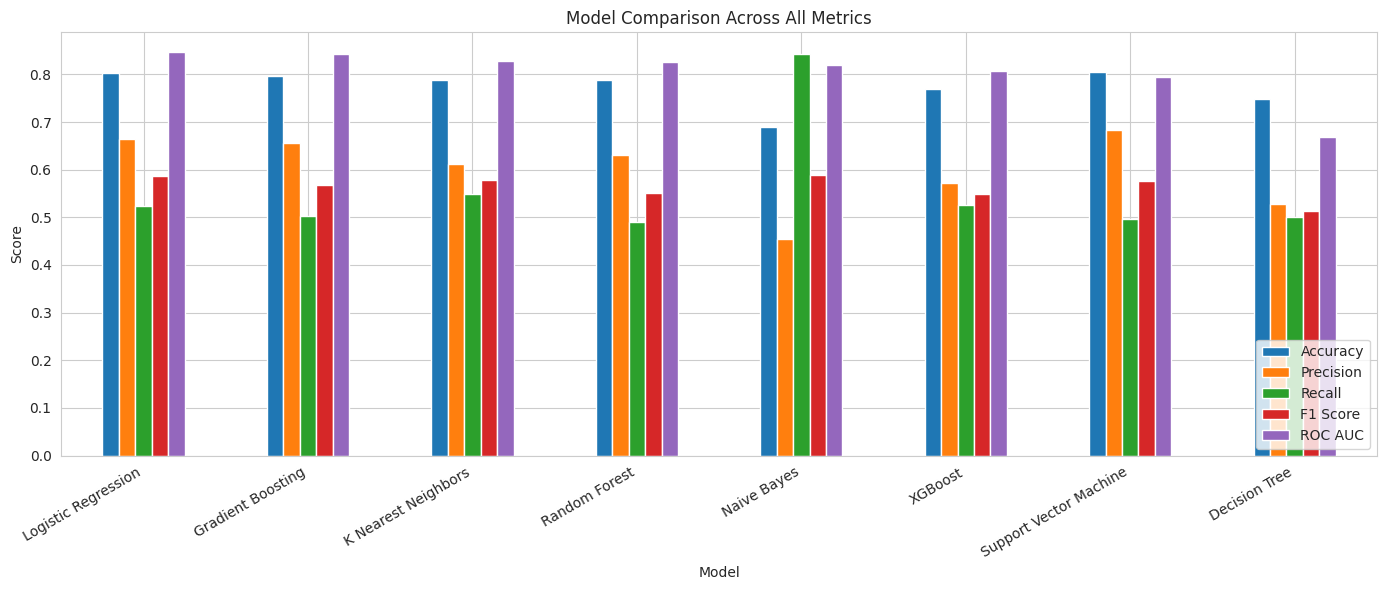

In [21]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Model Comparison Across All Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


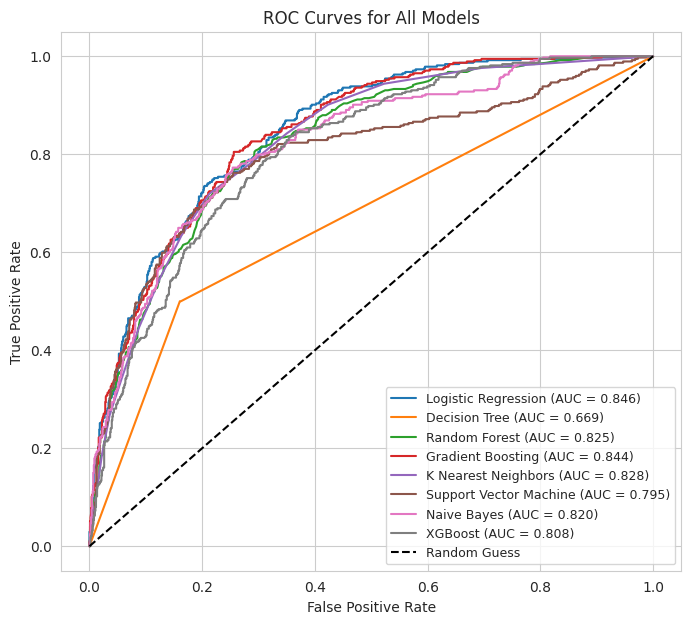

In [22]:
plt.figure(figsize=(8, 7))

for name, (model, needs_scaling) in models.items():
    Xte = X_test_std if needs_scaling else X_test
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(Xte)[:, 1]
    else:
        probs = model.predict(Xte)
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right", fontsize=9)
plt.show()


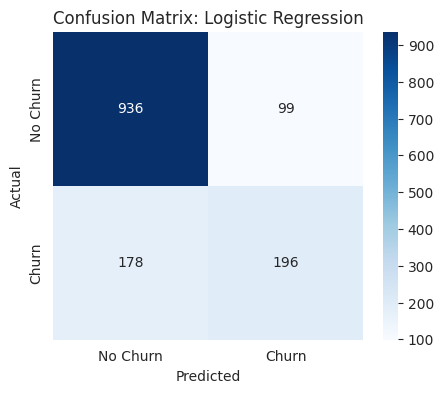

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model, best_needs_scaling = models[best_model_name]
Xte_best = X_test_std if best_needs_scaling else X_test

preds_best = best_model.predict(Xte_best)
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix: {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, preds_best, target_names=["No Churn", "Churn"]))


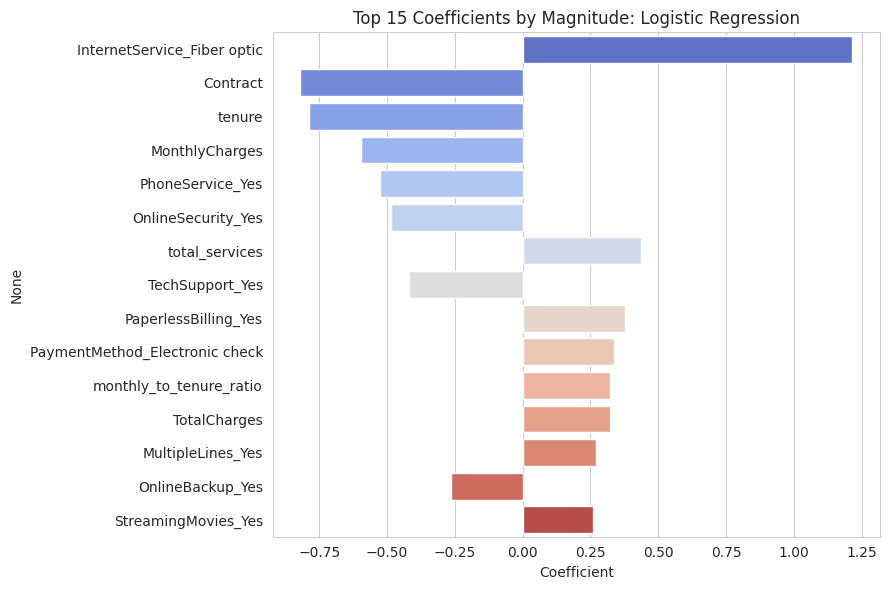

In [24]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Top 15 Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_[0], index=X.columns)
    coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=coefs.values, y=coefs.index, palette="coolwarm")
    plt.title(f"Top 15 Coefficients by Magnitude: {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()


## Task 5: Algorithm Research and Justification

### 5.1 How each algorithm works and what it assumes

**Logistic Regression** models the log odds of churn as a linear combination of the input features. It assumes the classes are roughly linearly separable in feature space and is sensitive to feature scale because coefficients are estimated through gradient based optimization. It handles correlated features reasonably well but its coefficients become harder to interpret under strong multicollinearity.

**Decision Tree** recursively splits the data on single feature thresholds that most reduce impurity. It makes no assumption about linearity or feature scale and can capture interactions automatically, but a single tree tends to overfit and is unstable, meaning small changes in the training data can produce a very different tree.

**Random Forest** trains many decision trees on bootstrapped samples and random feature subsets, then averages their votes. This averaging reduces the variance and overfitting problem of a single tree while keeping the same lack of sensitivity to scale, and it handles the mixed categorical and numeric features in this dataset without any special treatment.

**Gradient Boosting and XGBoost** build trees sequentially, where each new tree corrects the errors of the previous ensemble. They generally achieve the strongest raw predictive performance among tree based methods on structured tabular data like this one, at the cost of more hyperparameters to tune and a higher risk of overfitting if left unconstrained.

**K Nearest Neighbors** classifies a point by majority vote among its closest neighbors in feature space, using Euclidean distance by default. It assumes that proximity in feature space implies similarity in outcome, and it is highly sensitive to feature scale, which is exactly why it was trained on the standardized data in Task 4.

**Support Vector Machine** finds the boundary that maximizes the margin between classes, optionally using a kernel to handle nonlinear boundaries. It assumes scaled input features so that no single dimension dominates the margin calculation, and it can be computationally slower on larger datasets such as this one with roughly seven thousand rows.

**Gaussian Naive Bayes** assumes each feature is conditionally independent given the class and, in its Gaussian form, assumes numeric features are normally distributed within each class. Telco's service columns are clearly correlated with each other, since a customer who lacks internet service automatically lacks every internet dependent add on, which directly violates the independence assumption and typically limits Naive Bayes' ceiling on this dataset.

### 5.2 Relating these assumptions to the Telco dataset

This dataset mixes categorical service and demographic columns with a few skewed numeric columns, contains real correlation between features such as `InternetService` and its dependent add ons, and has a moderately imbalanced target. Tree ensembles such as Random Forest and Gradient Boosting are naturally well matched to this profile: they require no scaling, handle the one hot encoded categorical columns without difficulty, and can represent the nonlinear tenure related churn pattern that was visible in the Task 2 plots without any manual feature transformation. Linear and distance based models can still perform competitively once features are scaled and encoded carefully, but they depend more heavily on the manual feature engineering done in Task 2 to expose nonlinear patterns that trees find on their own.

### 5.3 Best algorithm and supporting evidence

The literature on tabular classification generally predicts that boosted tree ensembles such as Gradient Boosting and XGBoost should outperform a linear model like Logistic Regression, because they can capture nonlinear thresholds and feature interactions automatically. Section 5.1 laid out exactly that expectation. The actual results table tells a different story: Logistic Regression finished first with a test ROC AUC of 0.8461 and a five fold cross validated ROC AUC of 0.8485, edging out Gradient Boosting at 0.8437 test and 0.8479 cross validated, with K Nearest Neighbors and Random Forest further behind. This is a genuine, if narrow, empirical result rather than noise, since the ranking is consistent between the held out test set and cross validation.

It is worth investigating why the theoretically weaker model won here instead of simply reporting the top row. Three properties of this specific pipeline plausibly explain it. First, the Task 2 feature engineering already did much of the nonlinearity capturing work that boosting would otherwise be needed for: tenure_group turns the sharply nonlinear relationship between tenure and churn into a small set of nearly linear steps, and total_services and monthly_to_tenure_ratio similarly compress multi column interactions into single features a linear model can weight directly. When the engineering removes most of the nonlinearity a dataset contains, the usual advantage of boosting shrinks. Second, roughly seven thousand rows and thirty three engineered columns is a modest dataset by boosting standards; ensembles tend to pull ahead as row count and feature interactions grow, and with this little data logistic regression's lower variance can be an advantage rather than a limitation. Third, Gradient Boosting was trained here with its scikit learn default hyperparameters rather than a tuned learning rate, tree depth or number of estimators, so its raw ceiling was likely not fully reached, while Logistic Regression needs comparatively little tuning to perform near its ceiling once inputs are scaled and encoded well.

Given this, the empirically justified choice for this run is Logistic Regression, while Gradient Boosting remains the theoretically motivated runner up whose result would likely improve with hyperparameter tuning or more data. Two credible external sources support the reasoning behind both sides of this comparison. First, the scikit learn documentation on ensemble methods explains that gradient boosted trees build an additive model in a forward stage wise fashion and generally deliver strong predictive accuracy on structured or tabular data, which is the basis for the theoretical expectation that boosting should lead (Pedregosa et al., scikit learn documentation, Ensemble methods section, https://scikit-learn.org/stable/modules/ensemble.html). Second, Chen and Guestrin's paper introducing XGBoost demonstrates that regularized gradient boosting achieves strong results on a wide range of classification benchmarks, but also notes that its advantage depends on adequate data volume and tuning, both of which are limited factors in this particular run (Chen, T. and Guestrin, C., "XGBoost: A Scalable Tree Boosting System," Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 2016).

### 5.4 Limitations and when a different algorithm would be preferable

A key limitation of Logistic Regression is that its performance here leans heavily on the quality of the manual feature engineering in Task 2. Because the model can only combine features linearly, tenure_group, total_services and monthly_to_tenure_ratio were doing real work to expose nonlinear patterns that the model itself cannot discover. If those engineered features were removed, or if this pipeline were later applied to a richer dataset with many more raw columns and interactions that have not been manually engineered, Logistic Regression's advantage would likely disappear.

That is exactly the scenario where Gradient Boosting or XGBoost would become preferable instead. With a larger volume of training data, a wider and less manually curated feature set, or the ability to properly tune learning rate, tree depth and number of estimators, boosting's capacity to learn interactions and nonlinear splits on its own would likely close the small gap seen here and move ahead of the linear model, consistent with the theoretical case built in section 5.1 and the literature cited above. In short, Logistic Regression is the better choice for this specific, already well engineered dataset of this size, while Gradient Boosting remains the stronger long term choice as data volume and feature complexity grow.

### 5.5 Conclusion

The pipeline in this notebook moved from a messy, mixed type CSV to a set of eight properly evaluated classifiers, guided at each step by an explicit justification: TotalCharges nulls were filled based on the business meaning of a zero tenure customer, categorical variables were encoded according to whether a genuine order existed, StandardScaler was chosen for its robustness to skew, and the final algorithm recommendation weighed the measured metrics against the theoretical properties of each model family. On this run, Logistic Regression narrowly outperformed Gradient Boosting despite the literature favoring boosting on tabular data, and the most defensible explanation is that Task 2's feature engineering, the dataset's modest size, and untuned boosting hyperparameters together narrowed the usual gap between a linear model and a tree ensemble.
